# Sentiment analysis
This notebook contains an exploratory comparison and test of different sentiment analysis approaches on a sample of the SPoRC dataset to be used for the final analysis in the main notenbook.

In [12]:
# Dependencies

# Sentence segmentation
import spacy
nlp = spacy.load("en_core_web_sm")

# HuggingFace for RoBERTa
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# Data handling
import pandas as pd
import numpy as np
from tqdm import tqdm

In [13]:
# Helpers

def split_into_sentences(text: str):
    """
    Split text into sentences using spaCy.
    Returns a list of sentence strings.
    """
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

In [14]:
from helpers.sporc import (
    SPORCDataset,
    get_all_categories,
    get_main_categories,
    get_subcategories_list,
    is_main_category,
    is_subcategory,
    is_valid_category,
)
from pprint import pprint

sporc = SPORCDataset(local_data_dir="data", load_samples_only=True)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 6.29 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...


Loading episodes:   0%|          | 0/210000 [00:00<?, ?it/s]

INFO:helpers.sporc.dataset:✓ Separation completed in 0.25 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:helpers.sporc.dataset:✓ Grouping completed in 0.04 seconds
INFO:helpers.sporc.dataset:  Episodes grouped into 1826 podcasts
INFO:helpers.sporc.dataset:Creating Podcast and Episode objects...
INFO:helpers.sporc.dataset:✓ Object creation completed in 0.60 seconds
INFO:helpers.sporc.dataset:Loading speaker turn data for episodes...
INFO:helpers.sporc.dataset:Loading turn data for 200,000 speaker turn records...
INFO:helpers.sporc.dataset:Grouping turns by episode URL...
INFO:helpers.sporc.dataset:✓ Turn grouping completed in 0.13 seconds
INFO:helpers.sporc.dataset:  Turns grouped into 1,033 episodes
INFO:helpers.sporc.dataset:Loading turns for each episode...
INFO:helpers.sporc.dataset:✓ Turn loading completed in 2.84 seconds
INFO:helpers.sporc.dataset:  Episodes with turns: 1,0

In [33]:
# Get all episodes
episodes = sporc.get_all_episodes()
print(f"Loaded {len(episodes)} episodes from SPoRC.")

# Get subset of episodes (too slow for initial work otherwise)
import random
random.seed(42)
episodes = random.sample(episodes, 100)
print(f"Using {len(episodes)} random episodes for analysis.")

# Helper to pick a main "genre" label for an episode
all_main_categories = set(get_main_categories())

def get_episode_genre(ep):
    """
    Choose a single genre label for the episode.
    Strategy:
      1. If any category is a main category, use the first one.
      2. Otherwise, fall back to the first category if present.
      3. Else return None.
    """
    if getattr(ep, "categories", None):
        mains = [c for c in ep.categories if c in all_main_categories]
        if mains:
            return mains[0]
        return ep.categories[0]
    return None

rows = []

for ep_idx, episode in enumerate(tqdm(episodes, desc="Building sentence table")):
    genre = get_episode_genre(episode)
    turns = episode.get_all_turns()  # list of Turn objects

    sentence_idx = 0  # sentence index within this episode

    for turn in turns:
        text = getattr(turn, "text", None)
        if not text or not text.strip():
            continue

        # Sentence segmentation
        sentences = split_into_sentences(text)

        for sent in sentences:
            if not sent.strip():
                continue

            rows.append(
                {
                    "episode_index": ep_idx,                    # index in our list
                    "episode_title": episode.title,
                    "episode_date": getattr(episode, "episode_date", None),
                    "genre": genre,
                    "categories": episode.categories,
                    "speaker": getattr(turn, "primary_speaker", None),
                    "is_host_turn": getattr(turn, "is_host", None)
                    if hasattr(turn, "is_host")
                    else None,
                    "sentence": sent,
                    "sentence_idx": sentence_idx,              # for episode-relative time
                    "turn_word_count": getattr(turn, "word_count", None),
                    "turn_duration": getattr(turn, "duration", None),
                }
            )
            sentence_idx += 1

# Create the main sentences dataframe
sentences_df = pd.DataFrame(rows)
print(f"\nSentence-level table created with {len(sentences_df)} rows.")
print(sentences_df.head(6))

Loaded 10000 episodes from SPoRC.
Using 100 random episodes for analysis.


Building sentence table: 100%|██████████| 100/100 [00:18<00:00,  5.36it/s]


Sentence-level table created with 6378 rows.
   episode_index                                  episode_title  \
0              1  Dawain's SideBAR Why You Need A Podcast Coach   
1              1  Dawain's SideBAR Why You Need A Podcast Coach   
2              1  Dawain's SideBAR Why You Need A Podcast Coach   
3              1  Dawain's SideBAR Why You Need A Podcast Coach   
4              1  Dawain's SideBAR Why You Need A Podcast Coach   
5              1  Dawain's SideBAR Why You Need A Podcast Coach   

         episode_date   genre                         categories     speaker  \
0 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
1 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
2 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
3 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
4 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
5 20

In [34]:
# Load Siebert sentiment model and score sentences 

model_name = "siebert/sentiment-roberta-large-english"

# Load tokenizer & model (uses safetensors by default)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    trust_remote_code=True, 
    use_safetensors=True
)
model.eval()

# Label mapping for Siebert:
# 0 = negative
# 1 = positive
label_mapping = {0: "negative", 1: "positive"}

def score_siebert(sentences, batch_size=32, max_length=256):
    """
    Compute sentiment polarity + intensity using the Siebert model.
    Returns:
        - list of 'positive'/'negative' polarity labels
        - list of intensities (probability of predicted class)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    polarities = []
    intensities = []

    for i in tqdm(range(0, len(sentences), batch_size), desc="Siebert sentiment"):
        batch = sentences[i:i+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**enc)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)

        preds = torch.argmax(probs, dim=1).cpu().numpy()
        confs = torch.max(probs, dim=1).values.cpu().numpy()

        polarities.extend([label_mapping[p] for p in preds])
        intensities.extend(confs)

    return polarities, intensities


# Run Siebert on dataset

sentences_list = sentences_df["sentence"].tolist()

siebert_polarity, siebert_intensity = score_siebert(sentences_list)

sentences_df["polarity"] = siebert_polarity      # replaces roberta_polarity
sentences_df["intensity"] = siebert_intensity    # replaces roberta_intensity

print("Siebert sentiment columns added to sentences_df.")
sentences_df.head()


Siebert sentiment: 100%|██████████| 200/200 [20:38<00:00,  6.19s/it]

Siebert sentiment columns added to sentences_df.


,episode_index,episode_title,episode_date,genre,categories,speaker,is_host_turn,sentence,sentence_idx,turn_word_count,turn_duration,polarity,intensity
0,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,(upbeat music) -,0,734,321.38,positive,0.997787
1,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"Welcome to season three of ""Dwayne Sidebar.""",1,734,321.38,positive,0.998331
2,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"This is a sidebar from the original show, the ...",2,734,321.38,positive,0.990639
3,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"We're just me just talking to you, whether it'...",3,734,321.38,positive,0.998547
4,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,I hope you guys enjoy this show.,4,734,321.38,positive,0.998877


In [35]:
# Run VADER sentiment scoring as alternative for comparison to RoBERTa scoring
def score_vader(sentences):
    """
    Apply VADER to a list of sentences.
    Returns:
      - vader_score: compound score ∈ [-1, 1]
      - vader_polarity: negative / neutral / positive
    """
    scores = []
    labels = []

    for sent in tqdm(sentences, desc="VADER sentiment"):
        vs = vader.polarity_scores(sent)
        compound = vs["compound"]

        # Polarity thresholds from the VADER paper
        if compound >= 0.05:
            label = "positive"
        elif compound <= -0.05:
            label = "negative"
        else:
            label = "neutral"

        scores.append(compound)
        labels.append(label)

    return scores, labels


# Run VADER on sentences_df

vader_scores, vader_polarity = score_vader(sentences_df["sentence"].tolist())

sentences_df["vader_score"] = vader_scores
sentences_df["vader_polarity"] = vader_polarity

print("VADER sentiment columns added to sentences_df.")
sentences_df.head()

VADER sentiment: 100%|██████████| 6378/6378 [00:00<00:00, 26325.43it/s]

VADER sentiment columns added to sentences_df.


,episode_index,episode_title,episode_date,genre,categories,speaker,is_host_turn,sentence,sentence_idx,turn_word_count,turn_duration,polarity,intensity,vader_score,vader_polarity
0,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,(upbeat music) -,0,734,321.38,positive,0.997787,0.0000,neutral
1,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"Welcome to season three of ""Dwayne Sidebar.""",1,734,321.38,positive,0.998331,0.4588,positive
2,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"This is a sidebar from the original show, the ...",2,734,321.38,positive,0.990639,0.3182,positive
3,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"We're just me just talking to you, whether it'...",3,734,321.38,positive,0.998547,0.0000,neutral
4,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,I hope you guys enjoy this show.,4,734,321.38,positive,0.998877,0.7269,positive


In [36]:
# Episode-level sentiment time series (normalized 0–1 based on episode progress out of full episode elapsed time)

ts_df = sentences_df.copy()

# Normalize sentence_idx per episode

def normalize_episode_progress(df):
    df = df.sort_values(["episode_index", "sentence_idx"])
    df["episode_progress"] = (
        df.groupby("episode_index")["sentence_idx"]
        .transform(lambda x: x / x.max() if x.max() > 0 else 0)
    )
    return df

ts_df = normalize_episode_progress(ts_df)


# Convert categorical polarity to numeric values (Siebert: only positive / negative)
polarity_map_siebert = {
    "negative": -1,
    "positive": 1
}

ts_df["sentiment_num"] = ts_df["polarity"].map(polarity_map_siebert)

# VADER stays the same (still uses neutral)
polarity_map_vader = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

ts_df["vader_num"] = ts_df["vader_polarity"].map(polarity_map_vader)


# Smooth curves around mean

def smooth_episode(df, window=25):
    df = df.sort_values(["episode_index", "sentence_idx"])
    df["sentiment_smooth"] = (
        df.groupby("episode_index")["sentiment_num"]
        .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
    )
    df["vader_smooth"] = (
        df.groupby("episode_index")["vader_num"]
        .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
    )
    return df

ts_df = smooth_episode(ts_df)

# Final table
episode_timeseries_df = ts_df[
    [
        "episode_index",
        "episode_title",
        "genre",
        "episode_progress",
        "sentence",
        "sentence_idx",
        "sentiment_num",
        "intensity",
        "sentiment_smooth",
        "vader_num",
        "vader_score",
        "vader_smooth",
    ]
]

print("Episode-level time series dataframe created.")
episode_timeseries_df.head()


Episode-level time series dataframe created.


,episode_index,episode_title,genre,episode_progress,sentence,sentence_idx,sentiment_num,intensity,sentiment_smooth,vader_num,vader_score,vader_smooth
0,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.000000,(upbeat music) -,0,1,0.997787,0.384615,0,0.0000,0.307692
1,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.004274,"Welcome to season three of ""Dwayne Sidebar.""",1,1,0.998331,0.428571,1,0.4588,0.285714
2,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.008547,"This is a sidebar from the original show, the ...",2,1,0.990639,0.333333,1,0.3182,0.266667
3,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.012821,"We're just me just talking to you, whether it'...",3,1,0.998547,0.375000,0,0.0000,0.312500
4,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.017094,I hope you guys enjoy this show.,4,1,0.998877,0.411765,1,0.7269,0.294118


In [37]:
# Visualization of sentiment Time Series 

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# Plot sentiment for a single episode

def plot_episode_sentiment(df, episode_index, model="siebert", smooth=True):
    """
    Plot sentiment time series for one episode.
    model ∈ {"siebert", "vader"}
    """
    assert model in ["siebert", "vader"]

    ep = df[df["episode_index"] == episode_index]

    if ep.empty:
        print("Episode not found.")
        return

    title = ep["episode_title"].iloc[0]
    genre = ep["genre"].iloc[0]

    if model == "siebert":
        y = ep["sentiment_smooth"] if smooth else ep["sentiment_num"]
        label = "Siebert Sentiment"
    else:
        y = ep["vader_smooth"] if smooth else ep["vader_num"]
        label = "VADER Sentiment"

    plt.figure(figsize=(12, 4))
    plt.plot(ep["episode_progress"], y, label=label, alpha=0.9)
    plt.title(f"Sentiment Curve — Episode: {title} ({genre})")
    plt.xlabel("Episode Progress (0–1)")
    plt.ylabel("Sentiment (-1 to 1)")
    plt.ylim(-1.1, 1.1)
    plt.legend()
    plt.show()


# Plot average sentiment curve per genre

def plot_genre_average(df, model="siebert", smooth=True):
    """
    Compute and plot the average sentiment curve for each genre.
    model ∈ {"siebert", "vader"}
    """
    assert model in ["siebert", "vader"]

    if model == "siebert":
        y_col = "sentiment_smooth" if smooth else "sentiment_num"
    else:
        y_col = "vader_smooth" if smooth else "vader_num"

    df = df.copy()
    df["progress_bin"] = (df["episode_progress"] * 100).astype(int)

    grouped = (
        df.groupby(["genre", "progress_bin"])[y_col]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(14, 6))

    for genre in grouped["genre"].unique():
        sub = grouped[grouped["genre"] == genre]
        plt.plot(sub["progress_bin"], sub[y_col], label=genre, alpha=0.8)

    plt.title(f"Average Sentiment Curve by Genre ({model})")
    plt.xlabel("Episode Progress (%)")
    plt.ylabel("Average Sentiment")
    plt.ylim(-1.1, 1.1)
    plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Distribution of sentiment per genre

def plot_sentiment_distribution(df, model="siebert"):
    """
    Plot the distribution of sentiment polarity (numeric) per genre.
    """
    assert model in ["siebert", "vader"]

    y_col = "sentiment_num" if model == "siebert" else "vader_num"

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="genre", y=y_col, palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"Sentiment Distribution by Genre ({model})")
    plt.ylabel("Sentiment (-1 to 1)")
    plt.show()


# Compare Siebert and VADER for an episode

def plot_episode_comparison(df, episode_index, smooth=True):
    """
    Plot both Siebert and VADER curves for the same episode.
    """
    ep = df[df["episode_index"] == episode_index]

    if ep.empty:
        print("Episode not found.")
        return

    title = ep["episode_title"].iloc[0]
    genre = ep["genre"].iloc[0]

    r = ep["sentiment_smooth"] if smooth else ep["sentiment_num"]
    v = ep["vader_smooth"] if smooth else ep["vader_num"]

    plt.figure(figsize=(12, 4))
    plt.plot(ep["episode_progress"], r, label="Siebert", alpha=0.9)
    plt.plot(ep["episode_progress"], v, label="VADER", alpha=0.7)
    plt.title(f"Sentiment Comparison — Episode: {title} ({genre})")
    plt.xlabel("Episode Progress (0–1)")
    plt.ylabel("Sentiment (-1 to 1)")
    plt.ylim(-1.1, 1.1)
    plt.legend()
    plt.show()



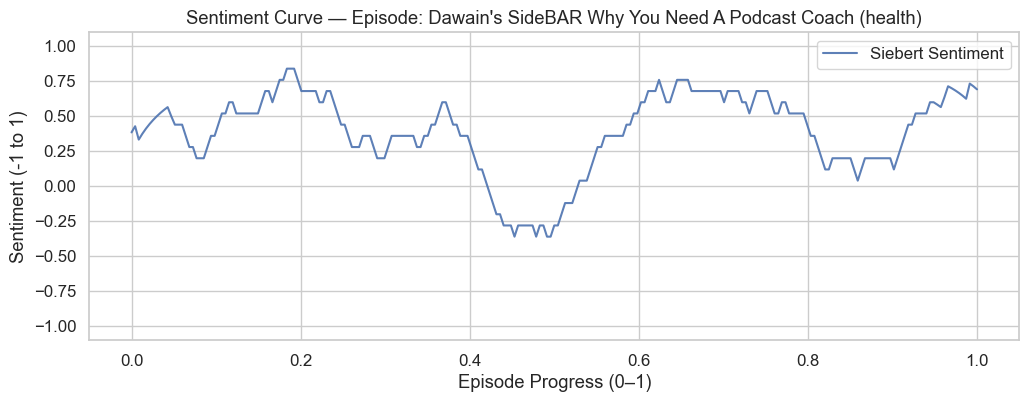

In [38]:
plot_episode_sentiment(episode_timeseries_df, episode_index=1)

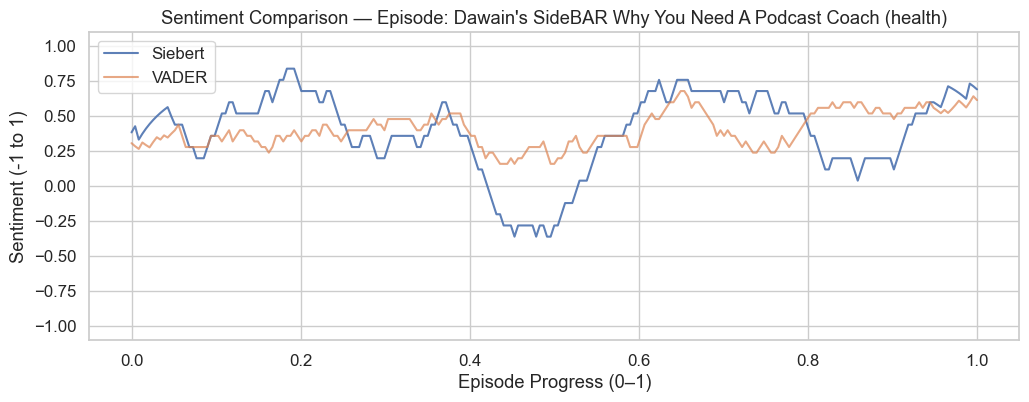

In [39]:
plot_episode_comparison(episode_timeseries_df, episode_index=1)

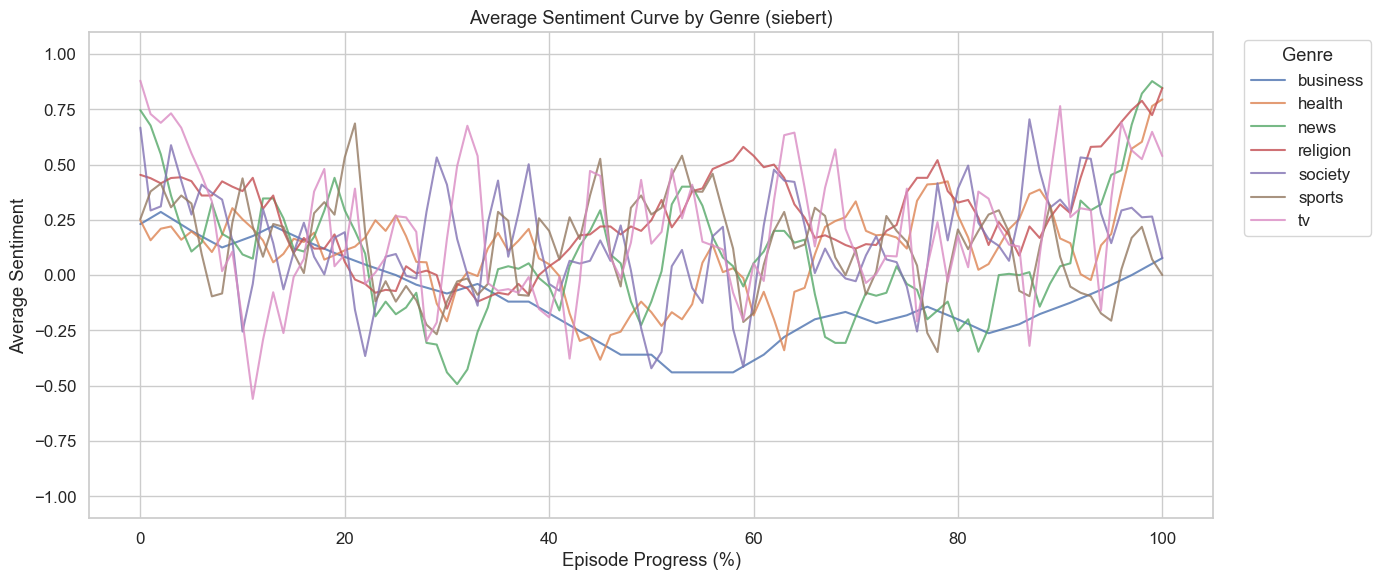

In [41]:
plot_genre_average(episode_timeseries_df, model="siebert")

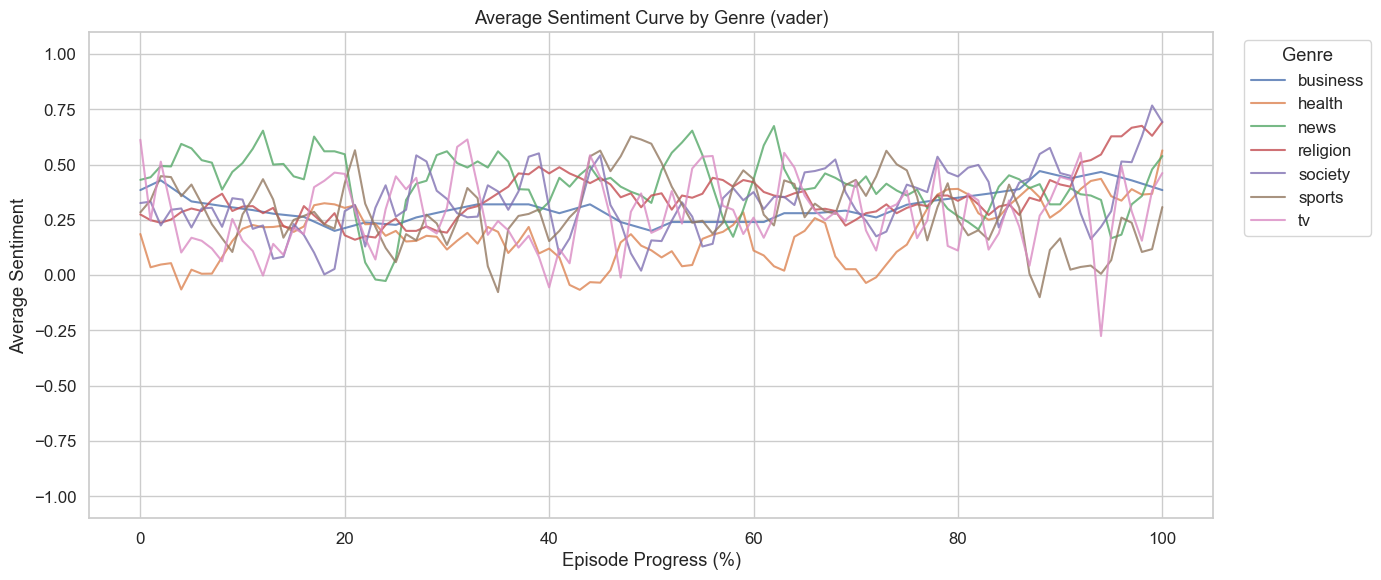

In [42]:
plot_genre_average(episode_timeseries_df, model="vader")

/var/folders/7b/z9f_qyjd6459ffds1s99zztr0000gn/T/ipykernel_82700/2878649357.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="genre", y=y_col, palette="Set2")


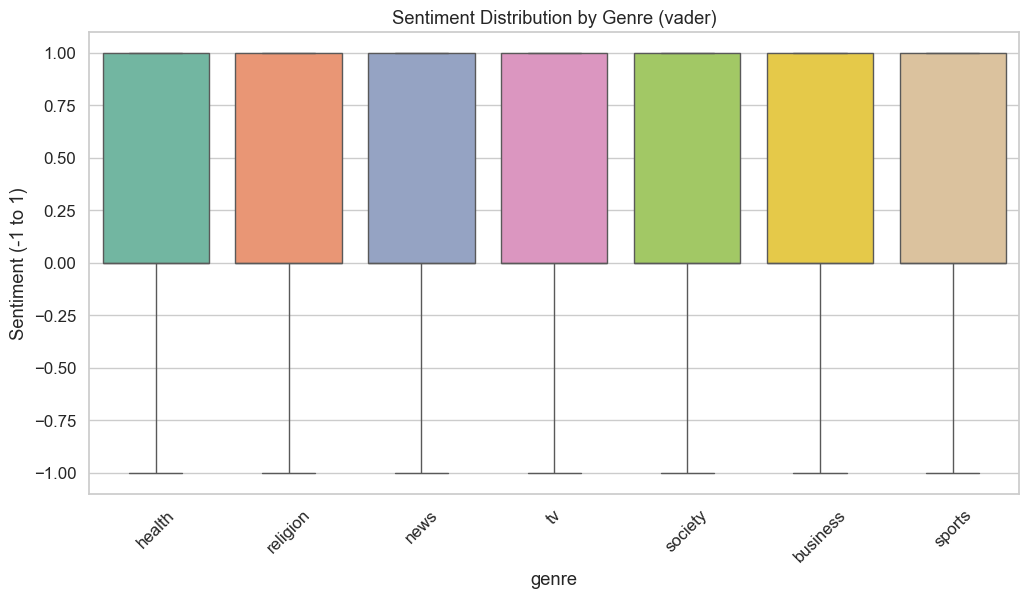

In [44]:
plot_sentiment_distribution(episode_timeseries_df, model="vader")

In [52]:
# Make numeric polarity for Siebert
sentences_df["sentiment_num"] = sentences_df["polarity"].map({"negative": -1, "positive": 1})

# Continuous, intensity-weighted sentiment in [-1, 1]
sentences_df["sentiment_weighted"] = sentences_df["sentiment_num"] * sentences_df["intensity"]

# Label balance
print(sentences_df["polarity"].value_counts(normalize=True))

# Confidence / intensity
print(sentences_df["intensity"].describe())

# Better genre-level signal (continuous)
print(sentences_df.groupby("genre")["sentiment_weighted"].mean().sort_values())

polarity
positive    0.576356
negative    0.423644
Name: proportion, dtype: float64
count    6378.000000
mean        0.983447
std         0.047931
min         0.510332
25%         0.988072
50%         0.995439
75%         0.998311
max         0.999505
Name: intensity, dtype: float64
genre
business   -0.020527
news        0.074548
health      0.112045
sports      0.135337
society     0.151527
tv          0.193338
religion    0.259346
Name: sentiment_weighted, dtype: float64


In [53]:
ep_level = (
    sentences_df
    .groupby(["episode_index","genre"])
    .agg(
        mean_sent=("sentiment_weighted","mean"),
        pos_rate=("sentiment_num", lambda x: (x==1).mean()),
        mean_intensity=("intensity","mean"),
        n_sentences=("sentence","size"),
    )
    .reset_index()
)

genre_summary = ep_level.groupby("genre").agg(
    mean_sent=("mean_sent","mean"),
    pos_rate=("pos_rate","mean"),
    mean_intensity=("mean_intensity","mean"),
    n_episodes=("episode_index","nunique"),
).sort_values("mean_sent", ascending=False)

print(genre_summary)

          mean_sent  pos_rate  mean_intensity  n_episodes
genre                                                    
religion   0.267822  0.633350        0.984834           2
sports     0.204373  0.602866        0.986241           2
tv         0.193338  0.596838        0.986748           1
health     0.187022  0.592663        0.987080           3
society    0.151527  0.576597        0.980242           1
news       0.074548  0.536624        0.982877           1
business  -0.020527  0.486486        0.985019           1


In [65]:
sentences_df["episode_index"].nunique(), sentences_df["genre"].nunique()

(11, 7)

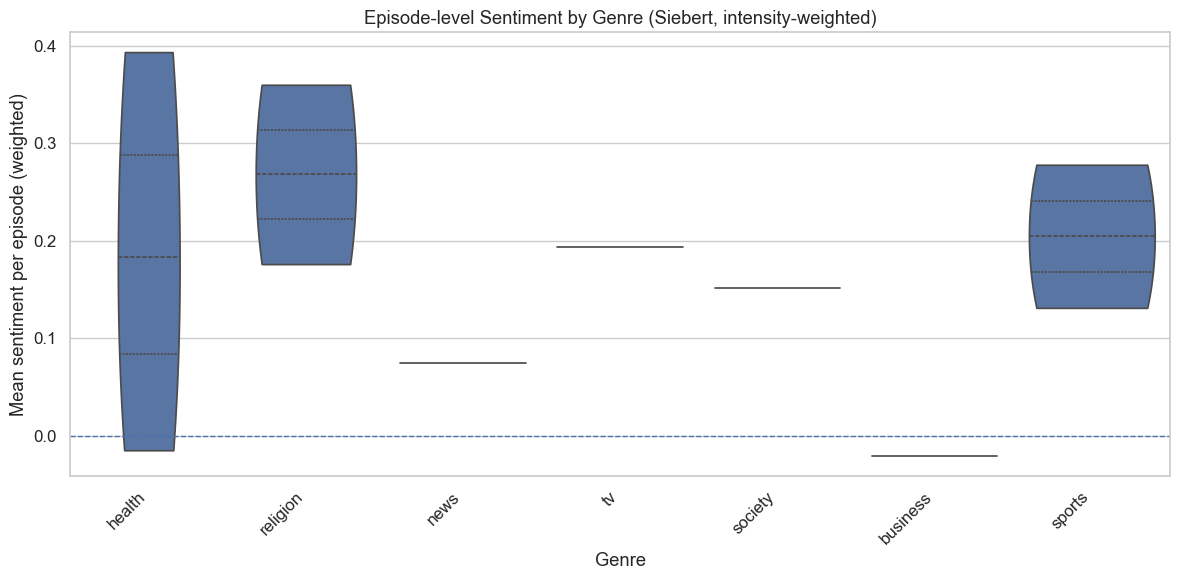

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.violinplot(data=ep_level, x="genre", y="mean_sent", inner="quartile", cut=0)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Episode-level Sentiment by Genre (Siebert, intensity-weighted)")
plt.ylabel("Mean sentiment per episode (weighted)")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

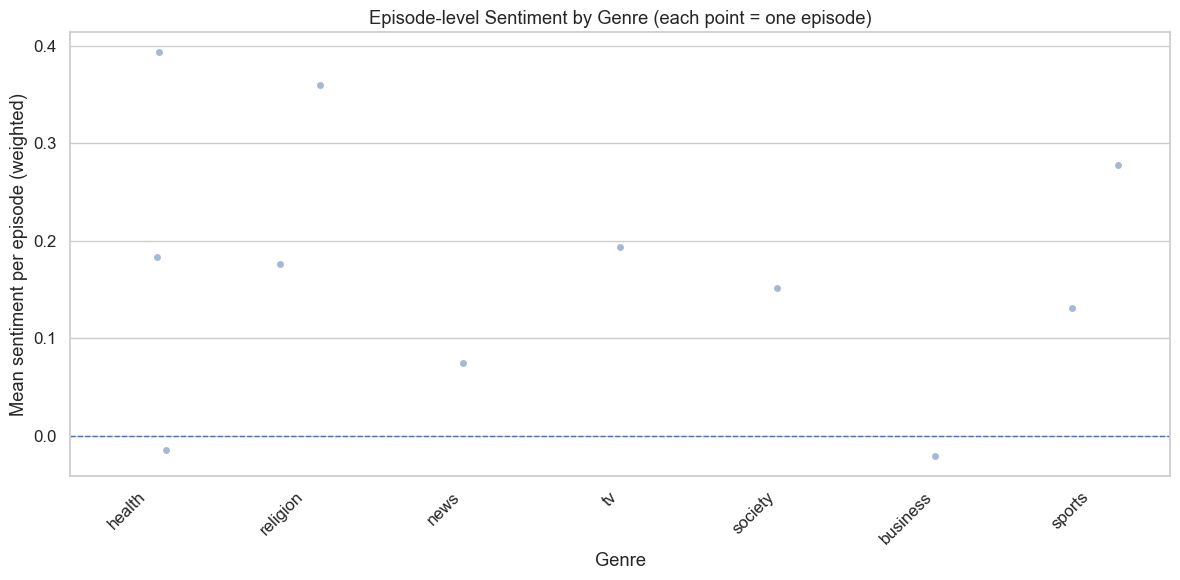

In [55]:
plt.figure(figsize=(12,6))
sns.stripplot(data=ep_level, x="genre", y="mean_sent", jitter=0.25, alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Episode-level Sentiment by Genre (each point = one episode)")
plt.ylabel("Mean sentiment per episode (weighted)")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()


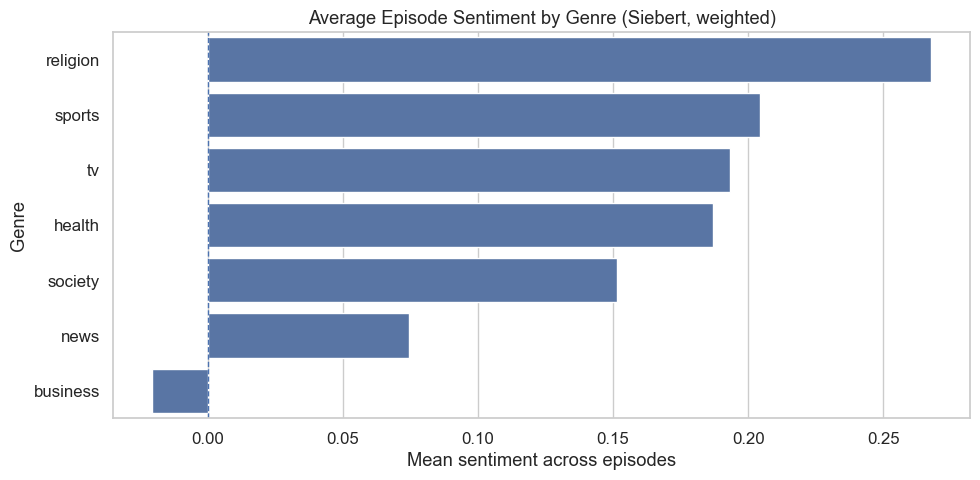

In [56]:
genre_summary = (
    ep_level.groupby("genre")
    .agg(mean_sent=("mean_sent","mean"), n_episodes=("episode_index","nunique"))
    .reset_index()
    .sort_values("mean_sent", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=genre_summary, x="mean_sent", y="genre", orient="h")
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Average Episode Sentiment by Genre (Siebert, weighted)")
plt.xlabel("Mean sentiment across episodes")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


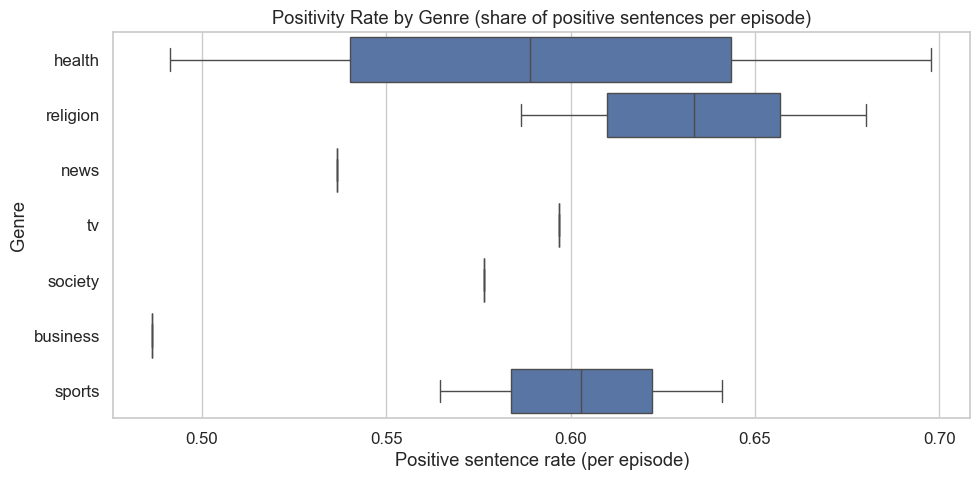

In [57]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ep_level, x="pos_rate", y="genre", orient="h")
plt.title("Positivity Rate by Genre (share of positive sentences per episode)")
plt.xlabel("Positive sentence rate (per episode)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


In [58]:
# Build continuous sentiment signal per sentence (Siebert)
sentences_df["sentiment_num"] = sentences_df["polarity"].map({"negative": -1, "positive": 1})
sentences_df["sentiment_weighted"] = sentences_df["sentiment_num"] * sentences_df["intensity"]

# Rebuild time-series df including weighted sentiment
ts_df = sentences_df.copy().sort_values(["episode_index", "sentence_idx"])

# Episode progress in [0,1]
ts_df["episode_progress"] = (
    ts_df.groupby("episode_index")["sentence_idx"]
    .transform(lambda x: x / x.max() if x.max() > 0 else 0)
)

# Smooth both the discrete and continuous signals
window = 25
ts_df["sentiment_smooth"] = (
    ts_df.groupby("episode_index")["sentiment_weighted"]
    .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
)

ts_df["vader_num"] = ts_df["vader_polarity"].map({"negative": -1, "neutral": 0, "positive": 1})
ts_df["vader_smooth"] = (
    ts_df.groupby("episode_index")["vader_num"]
    .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
)

episode_timeseries_df = ts_df[
    ["episode_index","episode_title","genre","episode_progress","sentence_idx",
     "sentence","sentiment_weighted","sentiment_smooth","vader_score","vader_num","vader_smooth"]
].copy()

episode_timeseries_df.head()


,episode_index,episode_title,genre,episode_progress,sentence_idx,sentence,sentiment_weighted,sentiment_smooth,vader_score,vader_num,vader_smooth
0,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.000000,0,(upbeat music) -,0.997787,0.354306,0.0000,0,0.307692
1,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.004274,1,"Welcome to season three of ""Dwayne Sidebar.""",0.998331,0.399760,0.4588,1,0.285714
2,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.008547,2,"This is a sidebar from the original show, the ...",0.990639,0.306477,0.3182,1,0.266667
3,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.012821,3,"We're just me just talking to you, whether it'...",0.998547,0.349651,0.0000,0,0.312500
4,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.017094,4,I hope you guys enjoy this show.,0.998877,0.387783,0.7269,1,0.294118


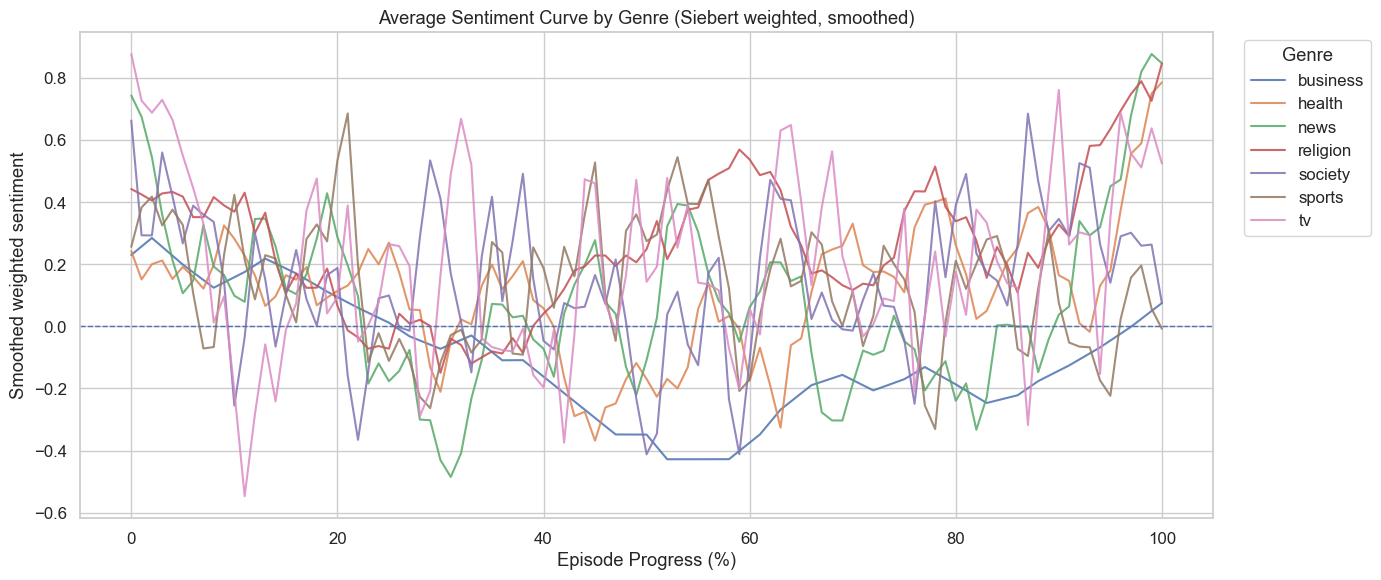

In [59]:
import matplotlib.pyplot as plt

df = episode_timeseries_df.copy()
df["progress_bin"] = (df["episode_progress"] * 100).astype(int)

grouped = df.groupby(["genre","progress_bin"])["sentiment_smooth"].mean().reset_index()

plt.figure(figsize=(14,6))
for g in grouped["genre"].unique():
    sub = grouped[grouped["genre"] == g]
    plt.plot(sub["progress_bin"], sub["sentiment_smooth"], label=g, alpha=0.85)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average Sentiment Curve by Genre (Siebert weighted, smoothed)")
plt.xlabel("Episode Progress (%)")
plt.ylabel("Smoothed weighted sentiment")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


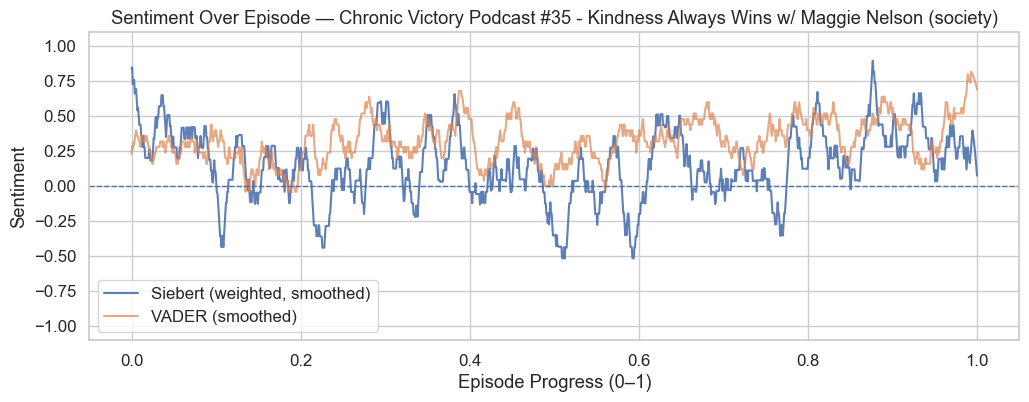

In [61]:
episode_timeseries_df["episode_index"].drop_duplicates().sample(5, random_state=42).tolist()
ep_id = episode_timeseries_df["episode_index"].drop_duplicates().sample(1, random_state=42).iloc[0]
ep = episode_timeseries_df[episode_timeseries_df["episode_index"] == ep_id]

plt.figure(figsize=(12,4))
plt.plot(ep["episode_progress"], ep["sentiment_smooth"], label="Siebert (weighted, smoothed)", alpha=0.9)
plt.plot(ep["episode_progress"], ep["vader_smooth"], label="VADER (smoothed)", alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Sentiment Over Episode — {ep['episode_title'].iloc[0]} ({ep['genre'].iloc[0]})")
plt.xlabel("Episode Progress (0–1)")
plt.ylabel("Sentiment")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()


In [62]:
# EVALUATION

import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score
from datasets import load_dataset

# Ensure required columns exist
sentences_df["sentiment_num"] = sentences_df["polarity"].map({"negative": -1, "positive": 1})
sentences_df["vader_num"] = sentences_df["vader_polarity"].map({"negative": -1, "neutral": 0, "positive": 1})
sentences_df["sentiment_weighted"] = sentences_df["sentiment_num"] * sentences_df["intensity"]

# 1) Inter-method agreement (binary vs ordinal)
# Convert VADER to binary by excluding neutrals
binary_df = sentences_df[sentences_df["vader_polarity"] != "neutral"].copy()
kappa = cohen_kappa_score(binary_df["polarity"], binary_df["vader_polarity"])
print(f"Cohen’s κ (Siebert vs VADER, excluding VADER neutrals): {kappa:.3f}")

print("\nLabel proportions on the binary subset:")
display(binary_df[["polarity","vader_polarity"]].apply(lambda c: c.value_counts(normalize=True)))

# 2) Confidence-based inspection (no ground-truth needed)
low_conf = sentences_df.nsmallest(20, "intensity")[["sentence","polarity","intensity","vader_score","vader_polarity","genre"]]
high_conf = sentences_df.nlargest(20, "intensity")[["sentence","polarity","intensity","vader_score","vader_polarity","genre"]]

print("\n--- Lowest-confidence Siebert predictions (inspect for ambiguity/fillers) ---")
display(low_conf)

print("\n--- Highest-confidence Siebert predictions (should be clearly polar) ---")
display(high_conf)

# 3) Negation flip test (quick robustness)
test_phrases = [
    "This is good.",
    "I like this.",
    "That was amazing.",
    "This is bad.",
    "I hate this.",
    "That was terrible."
]
negated = [f"Not {p[0].lower()}{p[1:]}" for p in test_phrases]  # crude but useful

test_sents = test_phrases + negated
pred_pol, pred_int = score_siebert(test_sents, batch_size=16, max_length=96)

neg_test_df = pd.DataFrame({"sentence": test_sents, "pred": pred_pol, "conf": pred_int})
print("\n--- Negation Flip Test ---")
display(neg_test_df)

# 4) SST-2 sanity benchmark (pipeline correctness sanity)
sst2 = load_dataset("glue", "sst2")
eval_subset = sst2["validation"].shuffle(seed=42).select(range(500))

sst_sents = eval_subset["sentence"]
sst_labels = np.array(eval_subset["label"])  # 0=negative, 1=positive

sst_pred, sst_conf = score_siebert(sst_sents, batch_size=32, max_length=96)
sst_pred_bin = np.array([1 if p == "positive" else 0 for p in sst_pred])

acc = accuracy_score(sst_labels, sst_pred_bin)
print(f"\nSST-2 sanity accuracy on 500 validation sentences: {acc:.3f}")

print("\nClassification report (SST-2 subset):")
print(classification_report(sst_labels, sst_pred_bin, target_names=["neg","pos"]))


Cohen’s κ (Siebert vs VADER, excluding VADER neutrals): 0.329

Label proportions on the binary subset:


,polarity,vader_polarity
positive,0.608095,0.800835
negative,0.391905,0.199165



--- Lowest-confidence Siebert predictions (inspect for ambiguity/fillers) ---


,sentence,polarity,intensity,vader_score,vader_polarity,genre
2925,different,negative,0.510332,0.0000,neutral,health
4319,saw this I saw this YouTube of this rancher ye...,positive,0.512339,0.2023,positive,society
6080,...,positive,0.518162,0.0000,neutral,sports
2337,'s a,negative,0.527121,0.0000,neutral,tv
2924,'s a,negative,0.527121,0.0000,neutral,health
1969,a little scale,negative,0.528360,0.0000,neutral,tv
3863,control,negative,0.533365,0.0000,neutral,society
5879,"But you know, he's always got some crazy.",negative,0.540824,-0.4767,negative,sports
5562,driver.,negative,0.540843,0.0000,neutral,sports
3657,way,negative,0.549664,0.0000,neutral,society



--- Highest-confidence Siebert predictions (should be clearly polar) ---


...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Siebert sentiment: 100%|██████████| 16/16 [02:13<00:00,  8.33s/it]


SST-2 sanity accuracy on 500 validation sentences: 0.930

Classification report (SST-2 subset):
              precision    recall  f1-score   support

         neg       0.93      0.92      0.93       239
         pos       0.93      0.93      0.93       261

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



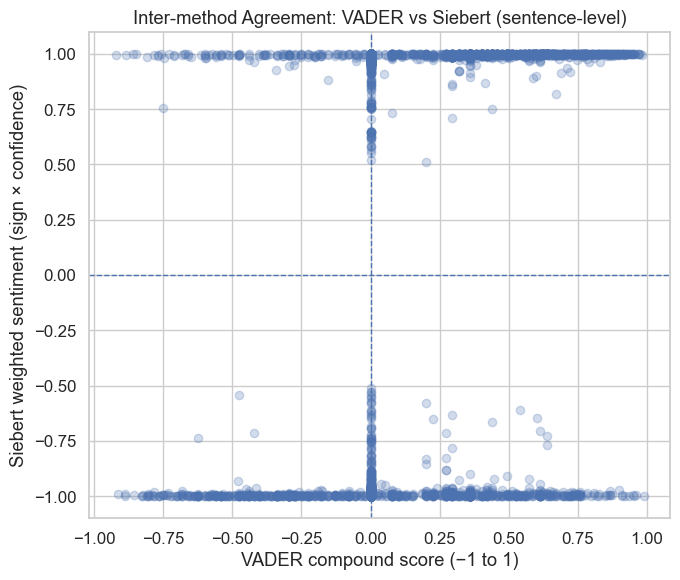

In [63]:
# Agreement plot: VADER score vs Siebert weighted sentiment

import matplotlib.pyplot as plt

# Ensure weighted sentiment exists
sentences_df["sentiment_num"] = sentences_df["polarity"].map({"negative": -1, "positive": 1})
sentences_df["sentiment_weighted"] = sentences_df["sentiment_num"] * sentences_df["intensity"]

# Sample for speed + readability (optional)
plot_df = sentences_df.sample(n=min(5000, len(sentences_df)), random_state=42).copy()

plt.figure(figsize=(7, 6))
plt.scatter(plot_df["vader_score"], plot_df["sentiment_weighted"], alpha=0.25)
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("VADER compound score (−1 to 1)")
plt.ylabel("Siebert weighted sentiment (sign × confidence)")
plt.title("Inter-method Agreement: VADER vs Siebert (sentence-level)")
plt.tight_layout()
plt.show()


In [64]:
from scipy.stats import spearmanr, pearsonr

rho, p = spearmanr(sentences_df["vader_score"], sentences_df["sentiment_weighted"])
r, p2 = pearsonr(sentences_df["vader_score"], sentences_df["sentiment_weighted"])

print("Spearman rho:", rho, "p-value:", p)
print("Pearson r:", r, "p-value:", p2)


Spearman rho: 0.38310292691241576 p-value: 4.55202033208407e-222
Pearson r: 0.27874766864782397 p-value: 3.679931780087637e-114
